<a href="https://colab.research.google.com/github/abyansyah052/NLP-1/blob/main/Week4_Assignment/TF_IDF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install xgboost tensorflow tensorflow_hub torch -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from timeit import default_timer as timer

is_cuda = torch.cuda.is_available()
device = torch.device("cuda" if is_cuda else "cpu")
print("GPU available" if is_cuda else "CPU used")

CPU used


In [2]:
df = pd.read_csv('/content/Tugas 1A Clean Data.csv')
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Shape: {df.shape}")
df.head()

Shape: (59965, 5)


,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,si bagus coba daftar login pdhl isi nik bnr se...,1,0.0,0.0,Negative
1,cepat bantu,5,0.0,0.0,Positive
2,mamtap,5,0.0,0.0,Positive
3,mantap 100 percaya,5,0.0,0.0,Positive
4,bagus bangett,5,0.0,0.0,Positive


In [3]:
def sentiment_label(score):
    if score >= 4:
        return "positive"
    elif score == 3:
        return "neutral"
    else:
        return "negative"

df['sentiment'] = df['score'].apply(sentiment_label)
print(df['sentiment'].value_counts())

x = df['content'].fillna('').astype(str)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['sentiment'])
print(f"Label classes: {label_encoder.classes_}")

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)
print(f"Train: {len(xtrain)}, Test: {len(xtest)}")

sentiment
positive    38421
negative    18654
neutral      2890
Name: count, dtype: int64
Label classes: ['negative' 'neutral' 'positive']
Train: 47972, Test: 11993


In [4]:
svm_clf = LinearSVC()
lr_clf  = LogisticRegression(max_iter=1000)
nb_clf  = MultinomialNB()
xgb_clf = XGBClassifier(eval_metric='mlogloss', verbosity=0)
rfc_clf = RandomForestClassifier(n_estimators=100, max_depth=3, max_features='sqrt',
                                  min_samples_leaf=4, bootstrap=True, n_jobs=-1, random_state=42)

def evaluate_model(model, xtest, ytest):
    y_pred    = model.predict(xtest)
    accuracy  = accuracy_score(ytest, y_pred)
    precision = precision_score(ytest, y_pred, average='weighted', zero_division=0)
    recall    = recall_score(ytest, y_pred, average='weighted', zero_division=0)
    f1        = f1_score(ytest, y_pred, average='weighted', zero_division=0)
    report    = classification_report(ytest, y_pred, zero_division=0)
    cm        = confusion_matrix(ytest, y_pred)
    return y_pred, accuracy, precision, recall, f1, report, cm

In [5]:
tfidf = TfidfVectorizer(max_features=5000)

start = timer()
xtrain_tfidf = tfidf.fit_transform(xtrain).toarray()
print(f"TF-IDF train: {xtrain_tfidf.shape} | time: {timer()-start:.2f}s")

start = timer()
xtest_tfidf  = tfidf.transform(xtest).toarray()
print(f"TF-IDF test : {xtest_tfidf.shape} | time: {timer()-start:.2f}s")

TF-IDF train: (47972, 5000) | time: 2.70s
TF-IDF test : (11993, 5000) | time: 0.75s


In [6]:
start = timer(); svm_tfidf = svm_clf.fit(xtrain_tfidf, ytrain); print(f"SVM : {timer()-start:.2f}s")
start = timer(); lr_tfidf  = lr_clf.fit(xtrain_tfidf, ytrain);  print(f"LR  : {timer()-start:.2f}s")
start = timer(); nb_tfidf  = nb_clf.fit(xtrain_tfidf, ytrain);  print(f"NB  : {timer()-start:.2f}s")
start = timer(); xgb_tfidf = xgb_clf.fit(xtrain_tfidf, ytrain); print(f"XGB : {timer()-start:.2f}s")
start = timer(); rfc_tfidf = rfc_clf.fit(xtrain_tfidf, ytrain); print(f"RFC : {timer()-start:.2f}s")

SVM : 17.97s
LR  : 101.40s
NB  : 0.65s
XGB : 158.68s
RFC : 9.44s


In [7]:
_, acc_svm, prec_svm, rec_svm, f1_svm, rep_svm, cm_svm   = evaluate_model(svm_tfidf,  xtest_tfidf, ytest)
_, acc_lr,  prec_lr,  rec_lr,  f1_lr,  rep_lr,  cm_lr    = evaluate_model(lr_tfidf,   xtest_tfidf, ytest)
_, acc_nb,  prec_nb,  rec_nb,  f1_nb,  rep_nb,  cm_nb    = evaluate_model(nb_tfidf,   xtest_tfidf, ytest)
_, acc_xgb, prec_xgb, rec_xgb, f1_xgb, rep_xgb, cm_xgb  = evaluate_model(xgb_tfidf,  xtest_tfidf, ytest)
_, acc_rfc, prec_rfc, rec_rfc, f1_rfc, rep_rfc, cm_rfc   = evaluate_model(rfc_tfidf,  xtest_tfidf, ytest)

models_tfidf = {
    'LinearSVM'         : (acc_svm, prec_svm, rec_svm, f1_svm, rep_svm, cm_svm),
    'LogisticRegression': (acc_lr,  prec_lr,  rec_lr,  f1_lr,  rep_lr,  cm_lr),
    'NaiveBayes'        : (acc_nb,  prec_nb,  rec_nb,  f1_nb,  rep_nb,  cm_nb),
    'XGBoost'           : (acc_xgb, prec_xgb, rec_xgb, f1_xgb, rep_xgb, cm_xgb),
    'RandomForest'      : (acc_rfc, prec_rfc, rec_rfc, f1_rfc, rep_rfc, cm_rfc),
}

for name, (acc, prec, rec, f1, rep, cm) in models_tfidf.items():
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"  Accuracy : {acc:.2f}")
    print(f"  Precision: {prec:.2f}")
    print(f"  Recall   : {rec:.2f}")
    print(f"  F1 Score : {f1:.2f}")
    print("  Classification Report:")
    print(rep)
    print("  Confusion Matrix:")
    print(cm)


  LinearSVM
  Accuracy : 0.85
  Precision: 0.82
  Recall   : 0.85
  F1 Score : 0.83
  Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.84      0.80      3668
           1       0.16      0.02      0.03       579
           2       0.90      0.92      0.91      7746

    accuracy                           0.85     11993
   macro avg       0.61      0.59      0.58     11993
weighted avg       0.82      0.85      0.83     11993

  Confusion Matrix:
[[3063   26  579]
 [ 318    9  252]
 [ 613   22 7111]]

  LogisticRegression
  Accuracy : 0.85
  Precision: 0.83
  Recall   : 0.85
  F1 Score : 0.83
  Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81      3668
           1       0.23      0.01      0.01       579
           2       0.89      0.93      0.91      7746

    accuracy                           0.85     11993
   macro avg       0.63      0.59      0.58

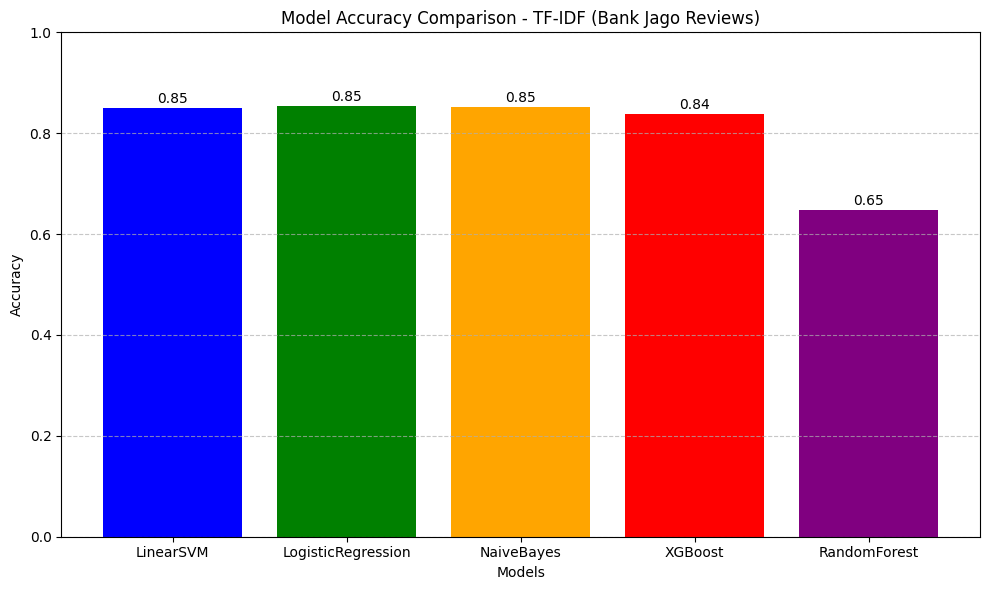

In [8]:
model_names = list(models_tfidf.keys())
model_accs  = [v[0] for v in models_tfidf.values()]

plt.figure(figsize=(10, 6))
plt.bar(model_names, model_accs, color=['blue', 'green', 'orange', 'red', 'purple'])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison - TF-IDF (Bank Jago Reviews)")
plt.ylim(0.0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(model_accs):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In [10]:
import tensorflow_hub as hub

batch_size = 1000

print("Loading USE model...")
start = timer()
embed = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")
print(f"USE loaded: {timer()-start:.2f}s")

xtrain_list = xtrain.tolist()
xtest_list  = xtest.tolist()

xtrain_use = []
for i in range(0, len(xtrain_list), batch_size):
    batch = xtrain_list[i:i+batch_size]
    xtrain_use.extend(np.array(embed(batch)))
print(f"xtrain embedded: {len(xtrain_use)}")

xtest_use = []
for i in range(0, len(xtest_list), batch_size):
    batch = xtest_list[i:i+batch_size]
    xtest_use.extend(np.array(embed(batch)))
print(f"xtest embedded: {len(xtest_use)}")

Loading USE model...
USE loaded: 35.14s
xtrain embedded: 47972
xtest embedded: 11993


In [11]:
start = timer(); svm_use = svm_clf.fit(xtrain_use, ytrain);  print(f"SVM : {timer()-start:.2f}s")
start = timer(); lr_use  = lr_clf.fit(xtrain_use, ytrain);   print(f"LR  : {timer()-start:.2f}s")
start = timer(); xgb_use = xgb_clf.fit(xtrain_use, ytrain);  print(f"XGB : {timer()-start:.2f}s")
start = timer(); rfc_use = rfc_clf.fit(xtrain_use, ytrain);  print(f"RFC : {timer()-start:.2f}s")

_, acc_svm_use, _, _, _, rep_svm_use, cm_svm_use = evaluate_model(svm_use, xtest_use, ytest)
_, acc_lr_use,  _, _, _, rep_lr_use,  cm_lr_use  = evaluate_model(lr_use,  xtest_use, ytest)
_, acc_xgb_use, _, _, _, rep_xgb_use, cm_xgb_use = evaluate_model(xgb_use, xtest_use, ytest)
_, acc_rfc_use, _, _, _, rep_rfc_use, cm_rfc_use  = evaluate_model(rfc_use, xtest_use, ytest)

for name, acc, rep, cm in [
    ("SVM USE",  acc_svm_use, rep_svm_use, cm_svm_use),
    ("LR USE",   acc_lr_use,  rep_lr_use,  cm_lr_use),
    ("XGB USE",  acc_xgb_use, rep_xgb_use, cm_xgb_use),
    ("RFC USE",  acc_rfc_use, rep_rfc_use, cm_rfc_use),
]:
    print(f"\n{'='*40}\n  {name}\n  Accuracy: {acc:.2f}")
    print(rep)
    print(cm)

SVM : 52.85s
LR  : 18.39s
XGB : 103.95s
RFC : 30.63s

  SVM USE
  Accuracy: 0.80
              precision    recall  f1-score   support

           0       0.70      0.71      0.71      3668
           1       0.00      0.00      0.00       579
           2       0.84      0.90      0.87      7746

    accuracy                           0.80     11993
   macro avg       0.51      0.54      0.52     11993
weighted avg       0.76      0.80      0.78     11993

[[2604    0 1064]
 [ 303    0  276]
 [ 806    0 6940]]

  LR USE
  Accuracy: 0.79
              precision    recall  f1-score   support

           0       0.70      0.71      0.70      3668
           1       1.00      0.00      0.00       579
           2       0.84      0.89      0.86      7746

    accuracy                           0.79     11993
   macro avg       0.84      0.53      0.52     11993
weighted avg       0.80      0.79      0.77     11993

[[2587    0 1081]
 [ 301    1  277]
 [ 825    0 6921]]

  XGB USE
  Accurac

In [12]:
import tensorflow as tf

xtrain_combined = tf.concat([tfidf_vectorizer_xtrain if 'tfidf_vectorizer_xtrain' in dir() else xtrain_tfidf, xtrain_use], axis=1)
xtest_combined  = tf.concat([tfidf_vectorizer_xtest  if 'tfidf_vectorizer_xtest'  in dir() else xtest_tfidf,  xtest_use],  axis=1)

start = timer(); svm_comb = svm_clf.fit(xtrain_combined, ytrain);  print(f"SVM : {timer()-start:.2f}s")
start = timer(); lr_comb  = lr_clf.fit(xtrain_combined, ytrain);   print(f"LR  : {timer()-start:.2f}s")
start = timer(); xgb_comb = xgb_clf.fit(xtrain_combined, ytrain);  print(f"XGB : {timer()-start:.2f}s")
start = timer(); rfc_comb = rfc_clf.fit(xtrain_combined, ytrain);  print(f"RFC : {timer()-start:.2f}s")

_, acc_svm_comb, _, _, _, _, _ = evaluate_model(svm_comb, xtest_combined, ytest)
_, acc_lr_comb,  _, _, _, _, _ = evaluate_model(lr_comb,  xtest_combined, ytest)
_, acc_xgb_comb, _, _, _, _, _ = evaluate_model(xgb_comb, xtest_combined, ytest)
_, acc_rfc_comb, _, _, _, _, _ = evaluate_model(rfc_comb, xtest_combined, ytest)

SVM : 224.68s
LR  : 143.87s
XGB : 267.30s
RFC : 25.03s


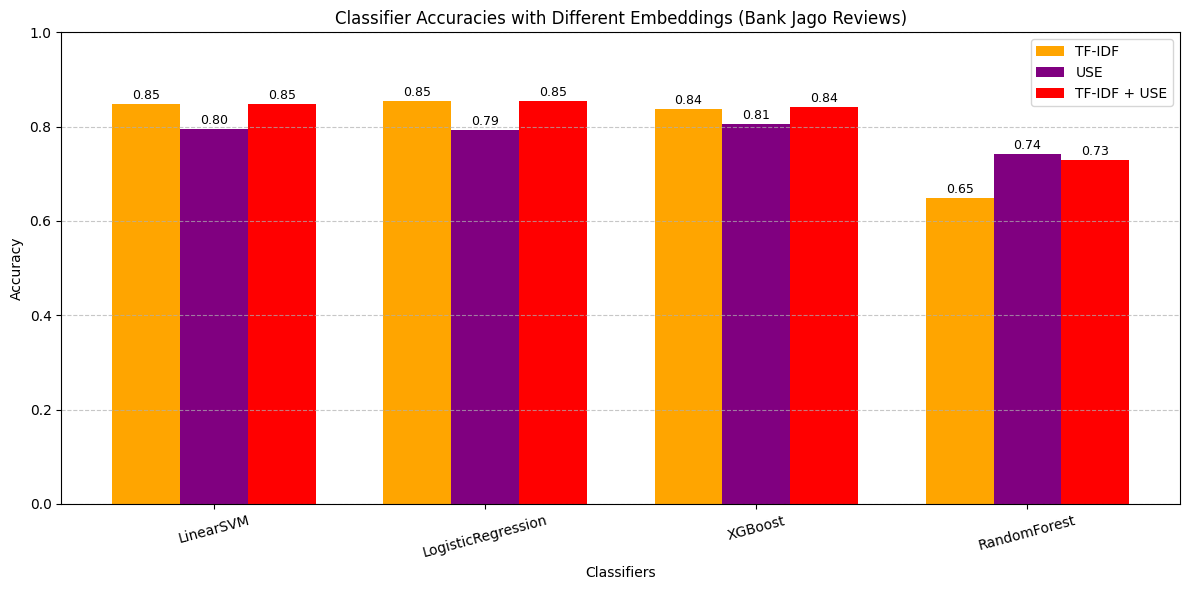

In [13]:

classifiers = ["LinearSVM", "LogisticRegression", "XGBoost", "RandomForest"]

tfidf_accs = [acc_svm, acc_lr, acc_xgb, acc_rfc]
use_accs   = [acc_svm_use, acc_lr_use, acc_xgb_use, acc_rfc_use]
comb_accs  = [acc_svm_comb, acc_lr_comb, acc_xgb_comb, acc_rfc_comb]

x         = np.arange(len(classifiers))
bar_width = 0.25

plt.figure(figsize=(12, 6))
plt.bar(x - bar_width, tfidf_accs, bar_width, label='TF-IDF',       color='orange')
plt.bar(x,             use_accs,   bar_width, label='USE',           color='purple')
plt.bar(x + bar_width, comb_accs,  bar_width, label='TF-IDF + USE',  color='red')

plt.xlabel('Classifiers')
plt.ylabel('Accuracy')
plt.title('Classifier Accuracies with Different Embeddings (Bank Jago Reviews)')
plt.xticks(x, classifiers, rotation=15)
plt.ylim(0, 1.0)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i in range(len(classifiers)):
    plt.text(x[i] - bar_width, tfidf_accs[i] + 0.01, f"{tfidf_accs[i]:.2f}", ha='center', fontsize=9)
    plt.text(x[i],             use_accs[i]   + 0.01, f"{use_accs[i]:.2f}",   ha='center', fontsize=9)
    plt.text(x[i] + bar_width, comb_accs[i]  + 0.01, f"{comb_accs[i]:.2f}",  ha='center', fontsize=9)

plt.tight_layout()
plt.show()